# A10
Zachary Fletcher

Market Basket Analysis - Walmart

# Task 1

In [ ]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=f90ffa0b850739a582d9a0a4bd239ebddbe1d52e3211dc252873b037334a96c1
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
# imports
from apyori import apriori
import pandas as pd

import csv
from urllib.request import urlopen
import io

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
url = 'https://raw.githubusercontent.com/matthewpecsok/4482_fall_2022/main/data/Walmart_baskets_1week_lst-1.csv'

with urlopen(url) as response:
    text_stream = io.TextIOWrapper(response, encoding='utf-8')
    reader = csv.reader(text_stream)
    data = list(reader)

# Task 2

In [ ]:
# show length of dataset
print(len(data))

#show first entry of dataset
print(data[0])

#show 10th and 15th entries
data[10:16]

2000
['FABRICS AND CRAFTS']


[['BRAS & SHAPEWEAR', 'PHARMACY OTC'],
 ['JEWELRY AND SUNGLASSES'],
 ['CANDY', ' TOBACCO', ' COOKIES', 'DSD GROCERY'],
 ['SHOES'],
 ['FINANCIAL SERVICES'],
 ['AUTOMOTIVE']]

In [ ]:
# flatten the list
flattened_data = [item for row in data for item in row]
flattened_data[0:20]

['FABRICS AND CRAFTS',
 'HARDWARE',
 'PERSONAL CARE',
 'PHARMACY OTC',
 'FROZEN FOODS',
 'PRODUCE',
 'SEAFOOD',
 'FROZEN FOODS',
 'LADIESWEAR',
 'FINANCIAL SERVICES',
 'FINANCIAL SERVICES',
 'CANDY',
 ' TOBACCO',
 ' COOKIES',
 'DSD GROCERY',
 'HOUSEHOLD PAPER GOODS',
 'BEAUTY',
 'FINANCIAL SERVICES',
 'IMPULSE MERCHANDISE',
 'BRAS & SHAPEWEAR']

<Axes: >

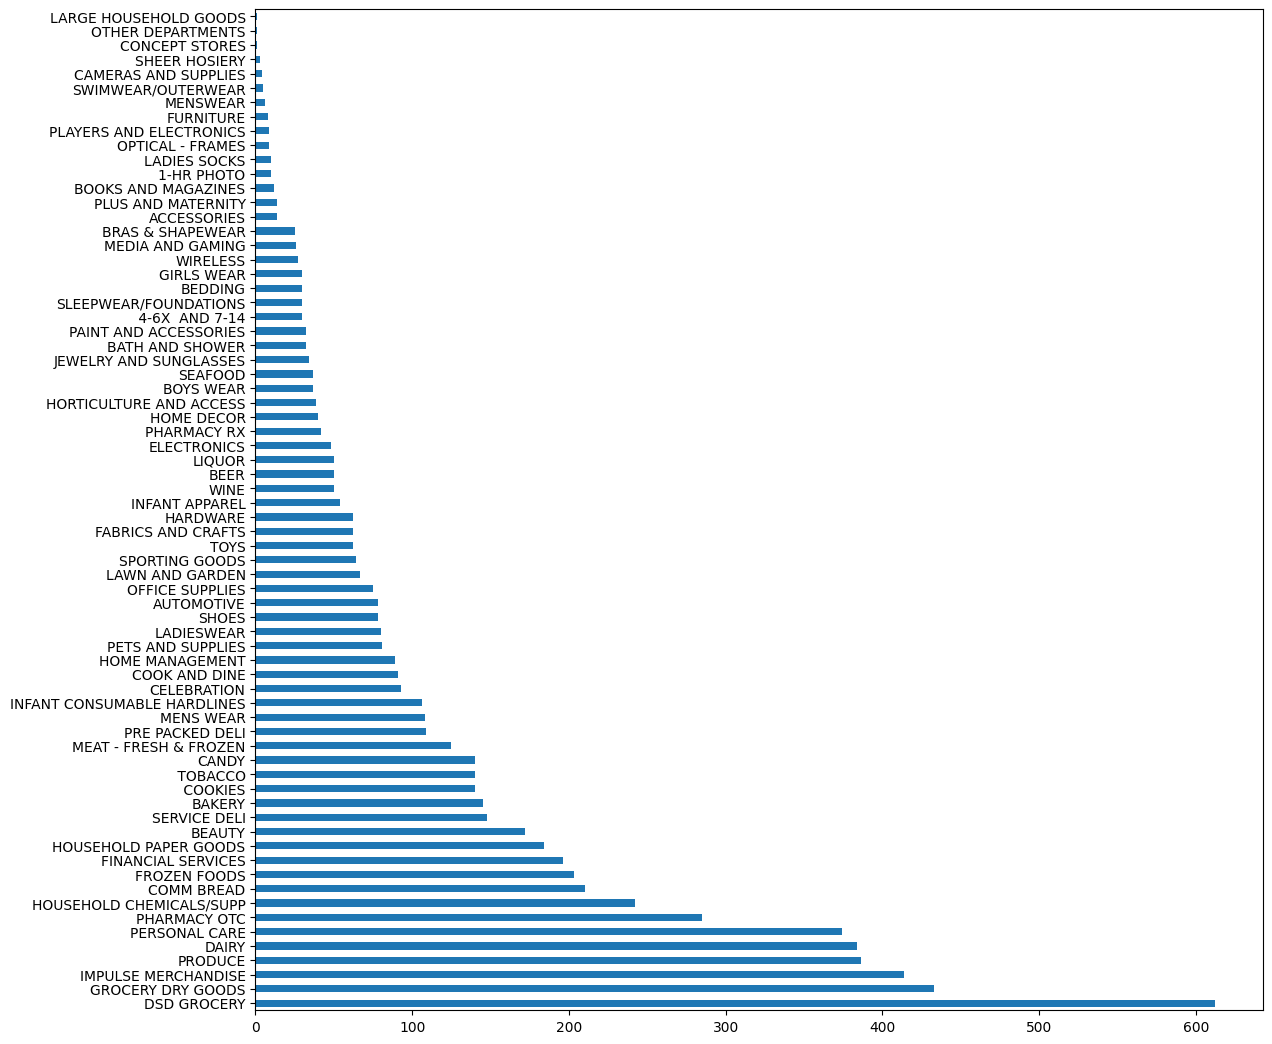

In [ ]:
# visualize frequency of each item
pd.get_dummies(flattened_data).sum().sort_values(ascending=False).plot(kind='barh', figsize=(13, 13))

# Task 3

In [ ]:
# show 10-15 items using apriori
association_rules = apriori(data, min_support=0.053, min_confidence=0.2, min_lift=3)
association_results = list(association_rules)

len(association_results)
association_results

[RelationRecord(items=frozenset({' TOBACCO', ' COOKIES'}), support=0.07, ordered_statistics=[OrderedStatistic(items_base=frozenset({' COOKIES'}), items_add=frozenset({' TOBACCO'}), confidence=1.0, lift=14.285714285714285), OrderedStatistic(items_base=frozenset({' TOBACCO'}), items_add=frozenset({' COOKIES'}), confidence=1.0, lift=14.285714285714285)]),
 RelationRecord(items=frozenset({' COOKIES', 'CANDY'}), support=0.07, ordered_statistics=[OrderedStatistic(items_base=frozenset({' COOKIES'}), items_add=frozenset({'CANDY'}), confidence=1.0, lift=14.285714285714285), OrderedStatistic(items_base=frozenset({'CANDY'}), items_add=frozenset({' COOKIES'}), confidence=1.0, lift=14.285714285714285)]),
 RelationRecord(items=frozenset({' TOBACCO', 'CANDY'}), support=0.07, ordered_statistics=[OrderedStatistic(items_base=frozenset({' TOBACCO'}), items_add=frozenset({'CANDY'}), confidence=1.0, lift=14.285714285714285), OrderedStatistic(items_base=frozenset({'CANDY'}), items_add=frozenset({' TOBACCO'}

In [ ]:
def parse_results(rules):
  for item in rules:
    pair = item[0]
    items = [x for x in pair]
    print("Rule: " + items[0] + " -> " + items[1])
    print("Support: " + str(item[1]))
    print("Confidence: " + str(item[2][0][2]))
    print("Lift: " + str(item[2][0][3]))
    print("-------------")

In [ ]:
# make a more readable version of the rules
parse_results(association_results)

Rule:  TOBACCO ->  COOKIES
Support: 0.07
Confidence: 1.0
Lift: 14.285714285714285
-------------
Rule:  COOKIES -> CANDY
Support: 0.07
Confidence: 1.0
Lift: 14.285714285714285
-------------
Rule:  TOBACCO -> CANDY
Support: 0.07
Confidence: 1.0
Lift: 14.285714285714285
-------------
Rule: DAIRY -> COMM BREAD
Support: 0.065
Confidence: 0.6190476190476191
Lift: 3.2242063492063493
-------------
Rule: GROCERY DRY GOODS -> COMM BREAD
Support: 0.0765
Confidence: 0.7285714285714285
Lift: 3.3652259980204553
-------------
Rule: FROZEN FOODS -> DAIRY
Support: 0.062
Confidence: 0.3229166666666667
Lift: 3.1814449917898195
-------------
Rule:  TOBACCO ->  COOKIES
Support: 0.07
Confidence: 1.0
Lift: 14.285714285714285
-------------
Rule: GROCERY DRY GOODS -> DAIRY
Support: 0.056
Confidence: 0.5333333333333333
Lift: 4.5584045584045585
-------------
Rule: DSD GROCERY -> GROCERY DRY GOODS
Support: 0.059
Confidence: 0.5619047619047619
Lift: 4.305783616128443
-------------
Rule: DSD GROCERY -> DAIRY
Suppor

Notes: I'm very suprised to find the people often buy tobacco, then cookies, cookies, and then candy. I notice that DSD grocery implies produce and dairy. Dairy is a frequently implied item with many other items.

In [ ]:
# use apriori to show 1-2 items
association_rules2 = apriori(data, min_support=0.076, min_confidence=0.2, min_lift=3)
association_results2 = list(association_rules2)

len(association_results2)

parse_results(association_results2)

Rule: GROCERY DRY GOODS -> COMM BREAD
Support: 0.0765
Confidence: 0.7285714285714285
Lift: 3.3652259980204553
-------------
Rule: DSD GROCERY -> DAIRY
Support: 0.09
Confidence: 0.46875
Lift: 3.5919540229885056
-------------


Notes: I notice that dry goods implies bread and DSD grocery implies dairy.

In [ ]:
!jupyter nbconvert --to html "/content/A10_Zachary_Fletcher.ipynb"

[NbConvertApp] Converting notebook /content/A10_Zachary_Fletcher.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 509452 bytes to /content/A10_Zachary_Fletcher.html
